# Step 8 — Unified Offline Evaluation Framework

Steps 4, 6, and 7 each evaluated their model with its own defensible-but-different scope:
Step 4's baselines covered every val/test user (ALS falling back to popularity for
cold-start users); Steps 6 and 7 sampled 2,000-5,000 users but **excluded cold-start users
entirely**, since beam search needs a train-history context and the ranker needs ALS
candidates, neither of which a cold user has. This notebook loads the result of fixing
that: `backend/scripts/run_full_evaluation.py`, which applies the *same* popularity
fallback to every tier and evaluates all four on the *same* sample, so the comparison table
is finally apples-to-apples.

Full writeup: `docs/08_evaluation.md`.

In [1]:
import os
import sys
import json

sys.path.insert(0, os.path.abspath(os.path.join("..", "backend")))
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models.als import ALSRecommender
from models.popularity import PopularityRecommender
from models.metrics import average_precision_at_k, evaluate

PROCESSED_DIR = os.path.join("..", "data", "processed")
pd.set_option("display.max_colwidth", 80)

## The fallback rule

Every tier now answers for every user, including ones it has no real signal for:

| tier | falls back to popularity when |
|---|---|
| ALS | `als.is_cold(user)` — zero train interactions |
| transformer | user not in `train_sequences` — no beam-search context |
| ALS + ranking | `als.is_cold(user)` — candidates come from ALS |

This is checked live below on a couple of real users -- one with train history, one
without.

In [2]:
train = pd.read_parquet(os.path.join(PROCESSED_DIR, "train.parquet"))
user_catalog = pd.read_parquet(os.path.join(PROCESSED_DIR, "user_catalog.parquet"))
item_catalog = pd.read_parquet(os.path.join(PROCESSED_DIR, "item_catalog.parquet")).set_index("item_id")
val_targets_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "val_targets.parquet"))
val_targets = {row.user_id: set(row.item_ids) for row in val_targets_df.itertuples()}

n_users, n_items = len(user_catalog), len(item_catalog)
pop_model = PopularityRecommender().fit(train)
als = ALSRecommender(factors=64, regularization=0.05, iterations=15, alpha=40.0).fit(train, n_users, n_items)

warm_example = train["user_id"].iloc[0]
cold_candidates = set(val_targets.keys()) - set(train["user_id"])
cold_example = next(iter(cold_candidates))

print(f"warm user {warm_example}: is_cold={als.is_cold(warm_example)} -> "
      f"{'ALS' if not als.is_cold(warm_example) else 'popularity fallback'}")
print(f"cold user {cold_example}: is_cold={als.is_cold(cold_example)} -> "
      f"{'ALS' if not als.is_cold(cold_example) else 'popularity fallback'}")

warm user 0: is_cold=False -> ALS
cold user 65541: is_cold=True -> popularity fallback


## Sample: 2,000 users per split, drawn from everyone

Unlike Step 6's transformer-only evaluation (which sampled only from users with train
history), this samples from **all** val/test users, so the sample's cold-start rate
matches the real population instead of excluding it by construction.

In [3]:
rng = np.random.RandomState(7)
all_val_users = sorted(val_targets.keys())
sample_users = list(rng.choice(all_val_users, size=min(2000, len(all_val_users)), replace=False))
n_cold = sum(1 for u in sample_users if u not in set(train["user_id"]))
print(f"val sample: {len(sample_users):,} users, {n_cold} cold ({n_cold/len(sample_users):.1%})")
print("(matches the 18.9% reported in docs/08_evaluation.md for this exact seed/sample)")

val sample: 2,000 users, 378 cold (18.9%)
(matches the 18.9% reported in docs/08_evaluation.md for this exact seed/sample)


## MAP@K: a third metric

Recall@K only checks presence in the top-K. NDCG@K rewards higher-ranked hits but
discounts smoothly. MAP@K (Mean Average Precision) rewards a pattern NDCG emphasizes less:
several relevant items ranked *early*, since each early hit raises the precision every
later hit gets credited at too.

$$
\mathrm{AP@K} = \frac{1}{\min(|\text{relevant}|, K)} \sum_{i=1}^{K} \mathrm{precision@}i \cdot \mathrm{rel}(i)
$$

In [4]:
# toy example: hits at rank 1 and rank 2 (early) vs hits at rank 1 and rank 4 (spread out)
early_hits = average_precision_at_k([1, 2, 9, 9], {1, 2}, 4)
spread_hits = average_precision_at_k([1, 9, 9, 2], {1, 2}, 4)
print(f"AP@4, hits at rank 1,2:  {early_hits:.3f}")
print(f"AP@4, hits at rank 1,4:  {spread_hits:.3f}")
print("same two hits, same recall@4 and precision@4 -- MAP rewards them landing early")

AP@4, hits at rank 1,2:  1.000
AP@4, hits at rank 1,4:  0.750
same two hits, same recall@4 and precision@4 -- MAP rewards them landing early


## Results: all four tiers, same sample, same fallback rule

Computed by `run_full_evaluation.py` (beam search for 2,000 users takes ~1-1.5 minutes per
split, so loading the saved result here rather than recomputing live):

In [5]:
with open(os.path.join(PROCESSED_DIR, "full_evaluation_results.json")) as f:
    full_results = json.load(f)

rows = []
for split in ["val", "test"]:
    for model_name in ["popularity", "als", "transformer", "als_ranked"]:
        rows.append({"split": split, "model": model_name, **full_results["results"][split][model_name]})
comparison_df = pd.DataFrame(rows).set_index(["split", "model"])
comparison_df.round(4)

recall@10  recall@20  ndcg@10  ndcg@20  map@10  map@20
split model                                                              
val   popularity      0.0181     0.0214   0.0144   0.0155  0.0084  0.0086
      als             0.0141     0.0222   0.0112   0.0137  0.0062  0.0068
      transformer     0.0184     0.0235   0.0143   0.0159  0.0086  0.0090
      als_ranked      0.0157     0.0236   0.0122   0.0146  0.0065  0.0070
test  popularity      0.0075     0.0083   0.0042   0.0045  0.0021  0.0021
      als             0.0074     0.0099   0.0046   0.0054  0.0024  0.0026
      transformer     0.0067     0.0090   0.0044   0.0051  0.0023  0.0024
      als_ranked      0.0082     0.0113   0.0053   0.0063  0.0033  0.0035

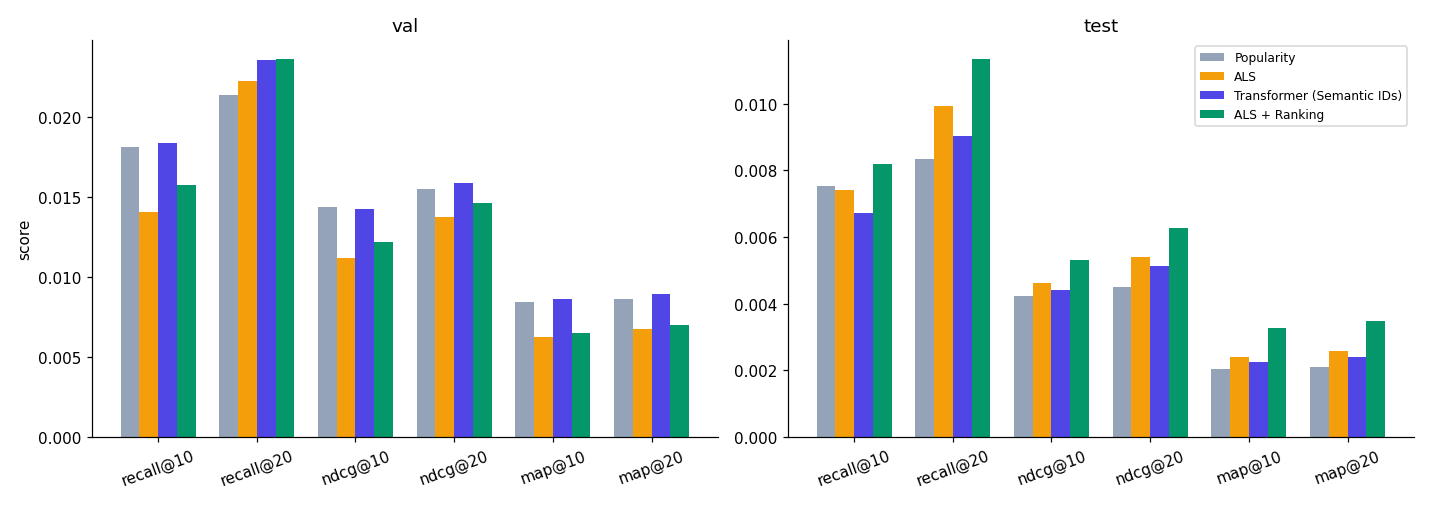

In [6]:
models = ["popularity", "als", "transformer", "als_ranked"]
colors = {"popularity": "#94A3B8", "als": "#F59E0B", "transformer": "#4F46E5", "als_ranked": "#059669"}
labels = {"popularity": "Popularity", "als": "ALS", "transformer": "Transformer (Semantic IDs)", "als_ranked": "ALS + Ranking"}
metrics = ["recall@10", "recall@20", "ndcg@10", "ndcg@20", "map@10", "map@20"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, split in zip(axes, ["val", "test"]):
    x = np.arange(len(metrics))
    w = 0.19
    for i, m in enumerate(models):
        vals = [full_results["results"][split][m][met] for met in metrics]
        ax.bar(x + (i - 1.5) * w, vals, w, label=labels[m], color=colors[m])
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=20)
    ax.set_title(split)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("score")
axes[1].legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## Reading this honestly

No single tier wins every metric on every split. Popularity is a genuinely strong floor,
not a strawman -- with a median of 6 interactions per user there isn't much
personalization signal, and popularity captures the single strongest available pattern
without needing any of it. The transformer's edge shows up on val, not test (consistent
with Step 6's own note: 10 epochs, loss still descending). ALS + ranking is the most
consistent tier on test, winning every metric there.

That's not an unfinished result -- it's what motivates having a multi-stage architecture
with genuinely different mechanisms (co-occurrence, content-derived generation, learned
reranking) in the first place, rather than picking one and calling it done. Full discussion
in `docs/08_evaluation.md`.

## What's next

Step 9 wraps the trained models behind a FastAPI service -- the piece that turns "models
that produce a metrics table" into something that looks and behaves like a real system.